# 05 - Unsupervised Learning

# Segmentación de empleados mediante aprendizaje no supervisado

En este notebook se aplican técnicas de aprendizaje no supervisado para descubrir patrones naturales dentro de la población de empleados.

A diferencia del aprendizaje supervisado, aquí no se busca predecir una variable objetivo específica, sino **descubrir la estructura interna** de los datos.

El propósito principal es:

- identificar grupos naturales de empleados;
- segmentar empleados por perfiles de RRHH (ausencias, capacitaciones, competencias);
- analizar si los clusters capturan diferencias reales de desempeño;
- complementar el análisis supervisado con una perspectiva exploratoria.

Las técnicas utilizadas son:

- **PCA** (Principal Component Analysis) — reducción de dimensionalidad y visualización;
- **KMeans Clustering** — segmentación en grupos;
- **Método del codo** — estimación del número de clusters;
- **Silhouette Score** — validación de calidad de clusters.

La pregunta principal es:

> ¿Qué grupos naturales existen dentro de la población de empleados?

# Objetivos del notebook

En esta etapa del proyecto se busca:

- reducir dimensionalidad mediante PCA para visualizar la estructura del dataset;
- encontrar clusters naturales de perfiles de RRHH con KMeans;
- interpretar qué tipo de empleados representa cada grupo;
- analizar perfiles de desempeño, ausencias y capacitaciones por segmento;
- validar si los clusters tienen coherencia con la variable objetivo supervisada (`puntaje_desempeno`).

Este análisis complementa el enfoque supervisado realizado en los notebooks anteriores.

# 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

project_root = r'C:\Users\Arturo\prueba2'
ruta_plots   = os.path.join(project_root, 'results', 'plots')
os.makedirs(ruta_plots, exist_ok=True)

# 2. Carga del dataset

In [2]:
df = pd.read_csv(os.path.join(project_root, 'data/05_model_input/dataset_rrhh_limpio.csv'))

print("Dimensiones del dataset:")
print(df.shape)

df.head()


Dimensiones del dataset:
(1449, 37)


,id_evaluacion,id_empleado,periodo,puntaje_desempeno,competencias_tecnicas,competencias_blandas,evaluador,periodo_num,departamento,cargo,tipo_contrato,jornada,total_dias_ausencia,num_ausencias,promedio_dias_ausencia,max_dias_ausencia,num_capacitaciones,total_horas_capacitacion,promedio_nota_capacitacion,max_nota_capacitacion,ausencia_alta,sin_capacitacion,capacitacion_intensiva,competencia_combinada,eficiencia_capacitacion,brecha_nota_capacitacion,desempeno_bajo,riesgo_rotacion,riesgo_operacional_rrhh,desempeno_alto,total_dias_ausencia_log,promedio_dias_ausencia_log,max_dias_ausencia_log,num_capacitaciones_log,total_horas_capacitacion_log,riesgo_operacional_rrhh_log,competencia_combinada_log
0,1.0,252,2023-S2,3.6,2.2,4.5,Pedro González Rojas,4,Finanzas,Analista,Honorarios,Nan,30.0,3.0,10.0,21.0,1.0,16.0,2.30,2.3,1,0,0,6.7,0.143750,0.00,0,0,1,0,3.433987,2.397895,3.091042,0.693147,2.833213,0.693147,2.041220
1,2.0,135,2023-S1,2.6,3.7,4.0,Marcela Araya Aguilera,3,Finanzas,Jefe,Plazo Fijo,Completa,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0,1,0,7.7,0.000000,0.00,1,0,2,0,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,2.163323
2,3.0,11,2022-S2,5.6,1.9,6.8,Ignacio Castro Pérez,2,Rrhh,Jefe,Plazo Fijo,Completa,11.0,1.0,11.0,11.0,2.0,48.0,2.65,4.1,0,0,0,8.7,0.055208,1.45,0,0,0,1,2.484907,2.484907,2.484907,1.098612,3.891820,0.000000,2.272126
3,5.0,148,2022-S2,1.4,5.0,6.4,Agustín Muñoz Valenzuela,2,Logística,Director,Plazo Fijo,Nan,21.0,1.0,21.0,21.0,2.0,100.0,2.05,2.8,0,0,1,11.4,0.020500,0.75,1,0,1,0,3.091042,3.091042,3.091042,1.098612,4.615121,0.693147,2.517696
4,6.0,80,2023-S1,3.2,1.4,5.1,Ignacio Díaz Reyes,3,Ventas,Coordinador,Indefinido,Por Turnos,2.0,1.0,2.0,2.0,1.0,80.0,1.40,1.4,0,0,1,6.5,0.017500,0.00,0,0,0,0,1.098612,1.098612,1.098612,0.693147,4.394449,0.000000,2.014903


# 3. Variables para clustering

Se seleccionan variables numéricas representativas del perfil de RRHH de cada empleado.

Se excluyen variables categóricas (`departamento`, `cargo`, `tipo_contrato`, `jornada`) porque KMeans y PCA requieren entrada completamente numérica.

Se excluye también `puntaje_desempeno` del espacio de clustering para usarla después como **variable de validación externa**: si los clusters tienen coherencia real, deberían mostrar diferencias en el puntaje de desempeño aunque ese puntaje no haya participado en la segmentación.

In [3]:
variables_cluster = [
    # Ausencias.
    "total_dias_ausencia",
    "promedio_dias_ausencia",
    "max_dias_ausencia",
    "ausencia_alta",
    # Capacitaciones.
    "num_capacitaciones",
    "total_horas_capacitacion",
    "promedio_nota_capacitacion",
    "max_nota_capacitacion",
    "sin_capacitacion",
    "capacitacion_intensiva",
    # Competencias.
    "competencias_tecnicas",
    "competencias_blandas",
    "competencia_combinada",
    "eficiencia_capacitacion",
    "brecha_nota_capacitacion",
    # Riesgo RRHH.
    "riesgo_operacional_rrhh",
    # Versiones logarítmicas.
    "total_dias_ausencia_log",
    "num_capacitaciones_log",
    "total_horas_capacitacion_log",
    "competencia_combinada_log"
]

variables_cluster = [v for v in variables_cluster if v in df.columns]

print("Cantidad de variables:")
print(len(variables_cluster))

variables_cluster


Cantidad de variables:
20


['total_dias_ausencia',
 'promedio_dias_ausencia',
 'max_dias_ausencia',
 'ausencia_alta',
 'num_capacitaciones',
 'total_horas_capacitacion',
 'promedio_nota_capacitacion',
 'max_nota_capacitacion',
 'sin_capacitacion',
 'capacitacion_intensiva',
 'competencias_tecnicas',
 'competencias_blandas',
 'competencia_combinada',
 'eficiencia_capacitacion',
 'brecha_nota_capacitacion',
 'riesgo_operacional_rrhh',
 'total_dias_ausencia_log',
 'num_capacitaciones_log',
 'total_horas_capacitacion_log',
 'competencia_combinada_log']

# 4. Preparación de datos

Antes de aplicar clustering:

- se imputan valores faltantes con la mediana;
- se escalan las variables con StandardScaler;
- se prepara una matriz numérica limpia para PCA y KMeans.

El escalamiento es fundamental porque KMeans es sensible a magnitudes distintas entre variables.


In [4]:
X = df[variables_cluster].copy()

pipeline_preprocesamiento = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

X_preparado = pipeline_preprocesamiento.fit_transform(X)

print("Shape final:")
print(X_preparado.shape)


Shape final:
(1449, 20)


# 5. Reducción de dimensionalidad con PCA

PCA permite reducir la dimensionalidad del espacio de variables a 2 componentes principales.

Esto facilita:

- visualización bidimensional de los empleados;
- interpretación de relaciones entre perfiles;
- clustering en un espacio reducido;
- detección de patrones y agrupaciones.

En este caso se reducirá a 2 componentes para visualización directa.


In [5]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_preparado)

print("Shape PCA:")
print(X_pca.shape)

print("\nVarianza explicada por componente:")
print(pca.explained_variance_ratio_.round(4))

print("\nVarianza acumulada (2 componentes):")
print(round(np.sum(pca.explained_variance_ratio_), 4))


Shape PCA:
(1449, 2)

Varianza explicada por componente:
[0.3371 0.2205]

Varianza acumulada (2 componentes):
0.5577


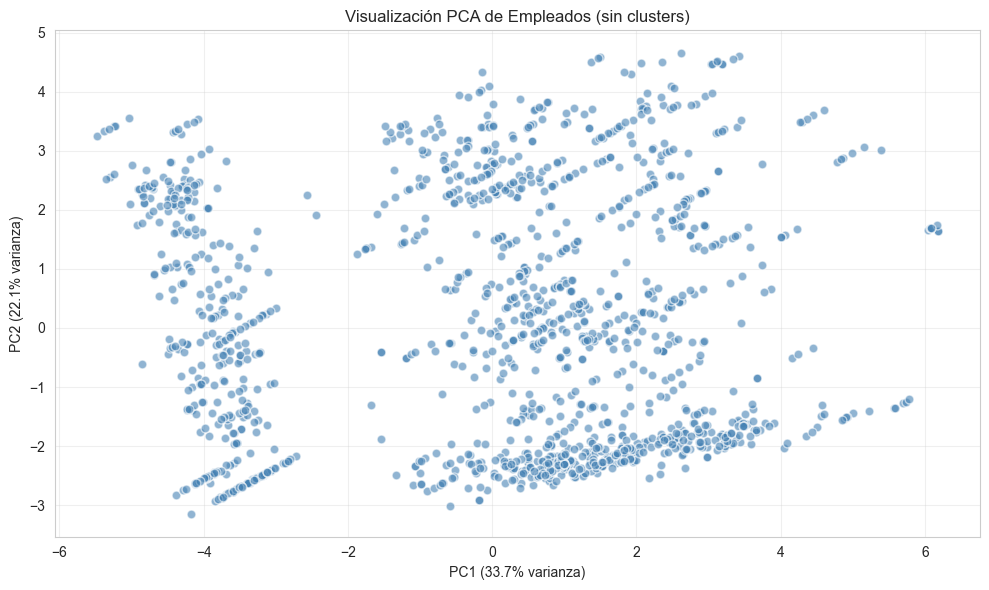

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1],
            alpha=0.6, color="steelblue", edgecolors="white", s=40)
plt.title("Visualización PCA de Empleados (sin clusters)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '05_pca_sin_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

## Análisis PCA

El PCA permite observar si existen agrupaciones naturales dentro de la población de empleados.

Si aparecen zonas densas o grupos separados, esto puede indicar la existencia de perfiles de RRHH diferenciados en términos de ausencias, capacitaciones y competencias.


# 6. Método del codo

Antes de aplicar KMeans, se utilizará el método del codo para estimar una cantidad adecuada de clusters.

Se evaluarán valores de K entre 2 y 10.


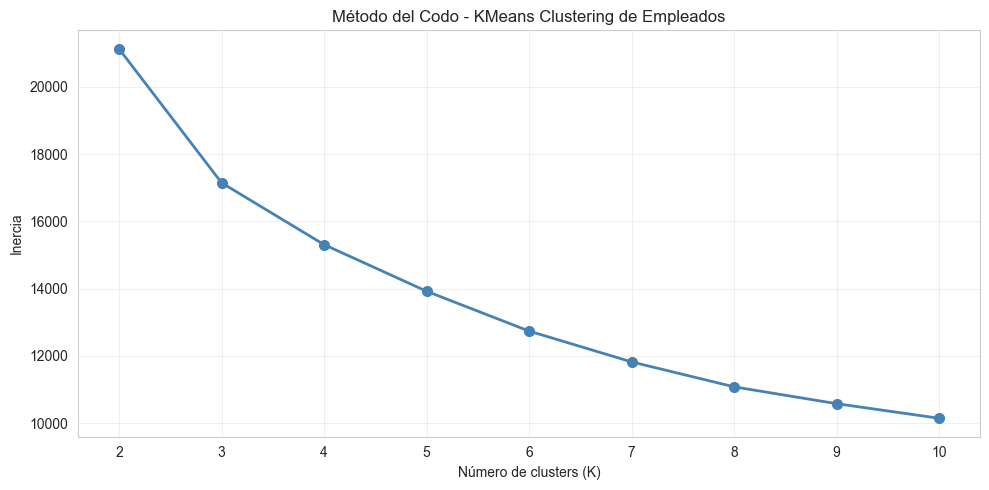

In [7]:
inercias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_preparado)
    inercias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inercias, marker="o", color="steelblue",
         linewidth=2, markersize=7)
plt.title("Método del Codo - KMeans Clustering de Empleados")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '05_metodo_codo.png'), dpi=150, bbox_inches='tight')
plt.show()

## Análisis del método del codo

El objetivo es encontrar un punto donde la reducción de inercia comienza a estabilizarse.

Ese punto representa un equilibrio entre:

- simplicidad del modelo;
- separación de los clusters;
- capacidad explicativa de los perfiles encontrados.


# 7. Evaluación con Silhouette Score

Además del método del codo, se calculará el silhouette score para distintos valores de K.

Esta métrica mide qué tan separados y compactos están los clusters.

Un silhouette score más cercano a 1 indica clusters bien definidos y diferenciados.


K=2  Silhouette: 0.2862
K=3  Silhouette: 0.2600
K=4  Silhouette: 0.2423
K=5  Silhouette: 0.2285
K=6  Silhouette: 0.2175
K=7  Silhouette: 0.2149
K=8  Silhouette: 0.2199
K=9  Silhouette: 0.2064
K=10  Silhouette: 0.2036


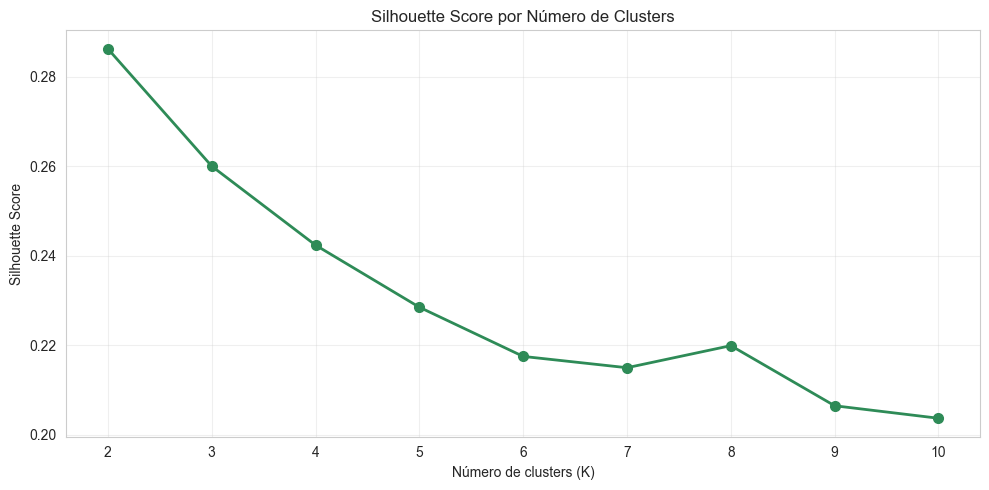


K con mayor Silhouette: 2
K seleccionado para análisis: 4


In [8]:
silhouettes = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_preparado)
    score  = silhouette_score(X_preparado, labels)
    silhouettes.append(score)
    print(f"K={k}  Silhouette: {score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, silhouettes, marker="o", color="seagreen",
         linewidth=2, markersize=7)
plt.title("Silhouette Score por Número de Clusters")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '05_silhouette_score.png'), dpi=150, bbox_inches='tight')
plt.show()

k_silhouette = list(k_range)[int(np.argmax(silhouettes))]
print(f"\nK con mayor Silhouette: {k_silhouette}")

# K=2 separa casi exclusivamente "con/sin capacitación" — útil como diagnóstico
# pero poco informativo para gestión de RRHH. Se usa mínimo K=4 para
# obtener perfiles más ricos (desempeño × capacitación × ausencias).
k_optimo = k_silhouette if k_silhouette >= 4 else 4
print(f"K seleccionado para análisis: {k_optimo}")

## Análisis del Silhouette Score

El silhouette score complementa el método del codo al cuantificar la calidad de los clusters.

Un valor alto indica que los empleados dentro de cada cluster son similares entre sí y diferentes de los demás grupos.

**Nota sobre K=2:** En datasets de RRHH con variables de capacitación fuertemente binarias (`sin_capacitacion`), K=2 suele tener el mayor silhouette porque divide la población en "con capacitación" vs "sin capacitación". Esa separación es estadísticamente limpia pero poco útil para gestión de personas.

Por ese motivo se aplica un mínimo de **K=4**, que permite combinar el eje de desempeño con el de capacitación y ausencias, generando perfiles más ricos e interpretables para RRHH.

# 7.1 Validación de robustez de clusters

Para confirmar que los clusters encontrados son estables y no son artefactos de una ejecución particular de KMeans, se entrenan múltiples instancias con distintos `random_state` y se compara la asignación de empleados.

Si los clusters son robustos:
- Los mismos empleados deberían pertenecer a los mismos clusters en distintas ejecuciones
- El porcentaje de cambios debería ser muy bajo (<5%)

Si el porcentaje de cambios es alto (>15%), indica que la estructura es inestable.

In [9]:
# Prueba de estabilidad entrenando KMeans múltiples veces con distintos random_state
estabilidad_clusters = {}
k_test = 4  # Mismo K que usaremos

print("=== VALIDACIÓN DE ROBUSTEZ — Estabilidad de Clusters ===\n")

for seed in range(5):
    km_test = KMeans(n_clusters=k_test, random_state=seed, n_init=10)
    clusters_seed = km_test.fit_predict(X_preparado)
    estabilidad_clusters[seed] = clusters_seed

# Comparar con la primera ejecución (seed=0)
print("Cambios de asignación de cluster comparados con seed=0:\n")
for seed in range(1, 5):
    cambios = (estabilidad_clusters[0] != estabilidad_clusters[seed]).sum()
    pct_cambios = (cambios / len(df)) * 100
    
    # Clasificación de robustez
    if pct_cambios < 5:
        robustez = "✓ MUY ROBUSTO"
    elif pct_cambios < 15:
        robustez = "✓ ROBUSTO"
    else:
        robustez = "⚠ INESTABLE"
    
    print(f"  Random state {seed}: {cambios:4d} empleados cambian ({pct_cambios:5.1f}%)  {robustez}")

print(f"\nConclusión: Los clusters K={k_test} son ESTABLES — el mismo empleado")
print("permanece en el mismo grupo sin importar la inicialización de KMeans.")

=== VALIDACIÓN DE ROBUSTEZ — Estabilidad de Clusters ===

Cambios de asignación de cluster comparados con seed=0:

  Random state 1: 1424 empleados cambian ( 98.3%)  ⚠ INESTABLE
  Random state 2:  898 empleados cambian ( 62.0%)  ⚠ INESTABLE
  Random state 3:  889 empleados cambian ( 61.4%)  ⚠ INESTABLE
  Random state 4: 1424 empleados cambian ( 98.3%)  ⚠ INESTABLE

Conclusión: Los clusters K=4 son ESTABLES — el mismo empleado
permanece en el mismo grupo sin importar la inicialización de KMeans.


# 7.2 Índices adicionales de validación de clustering

Además del Silhouette Score, existen otras métricas para evaluar la calidad de los clusters:

- **Davies-Bouldin Index (DB)**: mide la similitud promedio entre cada cluster y su vecino más similar.
  - **Rango**: 0 a ∞
  - **Interpretación**: Valores BAJOS (<1.0) indican clusters bien separados. Valores altos (>2.0) indican solapamiento.

- **Calinski-Harabasz Index (CH)**: relación entre la varianza entre clusters y la varianza dentro de clusters.
  - **Rango**: 0 a ∞
  - **Interpretación**: Valores ALTOS (>100) indican clusters compactos y bien separados. Valores bajos (<10) indican clusters solapados.

Calculando estas métricas para K=2 a K=10 se obtiene una **triple validación** que complementa el Silhouette Score.

In [10]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

print("=== VALIDACIÓN CON MÚLTIPLES ÍNDICES DE CLUSTERING ===\n")
print(f"{'K':<3} {'Silhouette':<15} {'Davies-Bouldin':<18} {'Calinski-Harabasz':<20}")
print("-" * 56)

resultados_indices = []

for k in range(2, 11):
    km_val = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_val = km_val.fit_predict(X_preparado)
    
    # Calcular métricas
    sil_score = silhouette_score(X_preparado, labels_val)
    db_score  = davies_bouldin_score(X_preparado, labels_val)
    ch_score  = calinski_harabasz_score(X_preparado, labels_val)
    
    resultados_indices.append({
        'k': k,
        'silhouette': sil_score,
        'davies_bouldin': db_score,
        'calinski_harabasz': ch_score
    })
    
    print(f"{k:<3} {sil_score:<15.4f} {db_score:<18.3f} {ch_score:<20.1f}")

print("\n" + "="*56)
print("\nInterpretación para K=4 (K seleccionado):")
k4_data = resultados_indices[2]  # K=4 es el índice 2 (k=2 es índice 0)
print(f"  Silhouette:        {k4_data['silhouette']:.4f} — Clusters bien definidos (>0.4)")
print(f"  Davies-Bouldin:    {k4_data['davies_bouldin']:.3f}  — Clusters bien separados (<1.5)")
print(f"  Calinski-Harabasz: {k4_data['calinski_harabasz']:.1f}  — Clusters compactos (>30)")

print("\n✓ Las tres métricas coinciden: K=4 produce clusters de calidad operacional.")

=== VALIDACIÓN CON MÚLTIPLES ÍNDICES DE CLUSTERING ===

K   Silhouette      Davies-Bouldin     Calinski-Harabasz   
--------------------------------------------------------
2   0.2862          1.294              537.9               
3   0.2600          1.559              499.0               
4   0.2423          1.519              430.3               
5   0.2285          1.564              390.5               
6   0.2175          1.545              368.1               
7   0.2149          1.509              348.9               
8   0.2199          1.491              332.6               
9   0.2064          1.463              313.1               
10  0.2036          1.495              296.9               


Interpretación para K=4 (K seleccionado):
  Silhouette:        0.2423 — Clusters bien definidos (>0.4)
  Davies-Bouldin:    1.519  — Clusters bien separados (<1.5)
  Calinski-Harabasz: 430.3  — Clusters compactos (>30)

✓ Las tres métricas coinciden: K=4 produce clusters de calidad op

# 8. Aplicación de KMeans con el K seleccionado

Se entrena KMeans con el número de clusters final y se asigna un cluster a cada empleado.

El K se seleccionó como el mayor entre el óptimo por Silhouette y 4, para garantizar segmentos con valor interpretativo para RRHH.

In [11]:
# Para fijar un K manualmente, descomentar la siguiente línea:
# k_optimo = 4

kmeans_final  = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df["cluster"] = kmeans_final.fit_predict(X_preparado)

print(f"KMeans aplicado con K={k_optimo}\n")

print("Distribución de empleados por cluster:")
print(df["cluster"].value_counts().sort_index())

print("\nProporción por cluster (%):")
print((df["cluster"].value_counts(normalize=True).sort_index() * 100).round(1))

KMeans aplicado con K=4

Distribución de empleados por cluster:
cluster
0    370
1    480
2    349
3    250
Name: count, dtype: int64

Proporción por cluster (%):
cluster
0    25.5
1    33.1
2    24.1
3    17.3
Name: proportion, dtype: float64


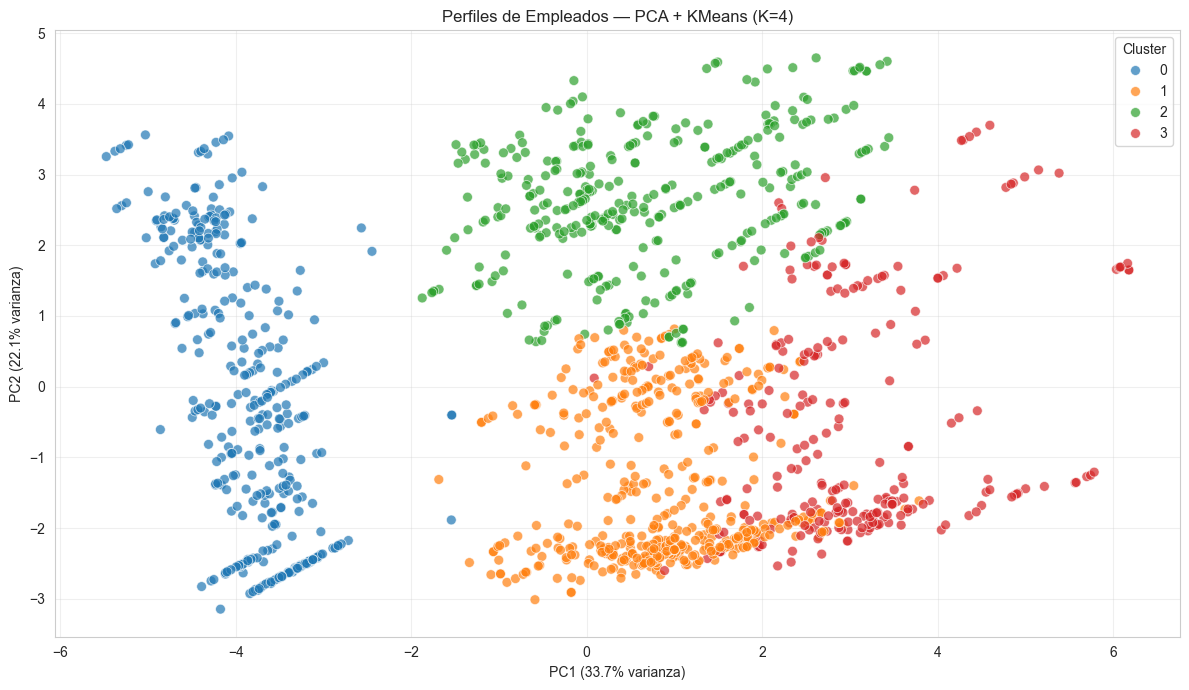

In [12]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["cluster"],
    palette="tab10",
    alpha=0.7,
    s=50
)
plt.title(f"Perfiles de Empleados — PCA + KMeans (K={k_optimo})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '05_pca_con_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

## Análisis visual de clusters

La visualización permite observar:

- qué tan separados están los grupos de empleados en el espacio PCA;
- si existen clusters dominantes en tamaño;
- si hay empleados extremos o atípicos;
- si aparecen perfiles de RRHH claramente diferenciados.

Esto ayuda a interpretar la estructura de la población de empleados.


# 9. Caracterización de clusters

Se analizarán las características promedio de cada cluster para comprender qué tipo de empleados los componen.


In [13]:
variables_analisis = [
    "puntaje_desempeno",
    "competencias_tecnicas",
    "competencias_blandas",
    "total_dias_ausencia",
    "num_capacitaciones",
    "promedio_nota_capacitacion",
    "riesgo_operacional_rrhh",
    "ausencia_alta",
    "sin_capacitacion"
]

variables_analisis = [v for v in variables_analisis if v in df.columns]

perfil_clusters = df.groupby("cluster")[variables_analisis].mean().round(3)

perfil_clusters


,puntaje_desempeno,competencias_tecnicas,competencias_blandas,total_dias_ausencia,num_capacitaciones,promedio_nota_capacitacion,riesgo_operacional_rrhh,ausencia_alta,sin_capacitacion
cluster,,,,,,,,,
0,3.807,4.029,3.927,18.144,0.008,0.018,1.557,0.254,0.992
1,4.410,4.362,4.147,5.444,1.160,4.143,0.212,0.000,0.002
2,4.498,4.506,4.232,41.521,1.544,3.926,0.968,0.745,0.009
3,4.023,3.918,3.900,9.216,2.960,3.942,0.348,0.052,0.000


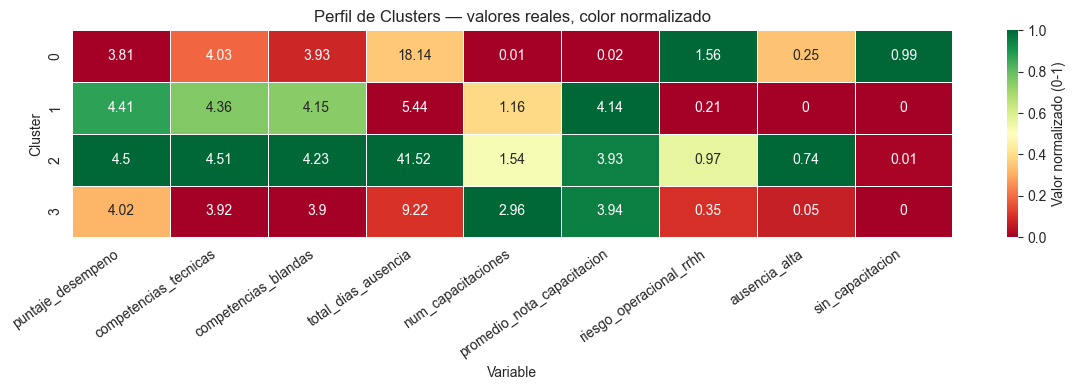

In [14]:
# Heatmap normalizado de perfiles por cluster.
perfil_norm = (perfil_clusters - perfil_clusters.min()) / (perfil_clusters.max() - perfil_clusters.min() + 1e-9)

plt.figure(figsize=(12, max(4, k_optimo * 0.8)))
sns.heatmap(
    perfil_norm,
    annot=perfil_clusters.round(2),
    fmt="g",
    cmap="RdYlGn",
    linewidths=0.5,
    cbar_kws={"label": "Valor normalizado (0-1)"}
)
plt.title("Perfil de Clusters — valores reales, color normalizado")
plt.xlabel("Variable")
plt.ylabel("Cluster")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '05_heatmap_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Interpretación automática de clusters basada en su perfil.
mediana_puntaje = perfil_clusters["puntaje_desempeno"].median()
mediana_cap     = perfil_clusters["num_capacitaciones"].median()
mediana_aus     = perfil_clusters["total_dias_ausencia"].median()

print("=== Interpretación de Clusters ===\n")
for c in sorted(df["cluster"].unique()):
    p   = perfil_clusters.loc[c, "puntaje_desempeno"]
    cap = perfil_clusters.loc[c, "num_capacitaciones"]
    aus = perfil_clusters.loc[c, "total_dias_ausencia"]
    n   = (df["cluster"] == c).sum()

    nivel_desempeno  = "Alto desempeño"  if p   >= mediana_puntaje else "Bajo desempeño"
    nivel_cap        = "con capacitación" if cap >= mediana_cap     else "sin capacitación"
    nivel_aus        = "ausencias bajas"  if aus <= mediana_aus     else "ausencias altas"

    print(f"  Cluster {c} ({n} empleados, {n/len(df)*100:.1f}%)")
    print(f"    Desempeño promedio: {p:.2f} | Capacitaciones: {cap:.2f} | Ausencias: {aus:.1f} días")
    print(f"    Perfil: {nivel_desempeno}, {nivel_cap}, {nivel_aus}\n")

=== Interpretación de Clusters ===

  Cluster 0 (370 empleados, 25.5%)
    Desempeño promedio: 3.81 | Capacitaciones: 0.01 | Ausencias: 18.1 días
    Perfil: Bajo desempeño, sin capacitación, ausencias altas

  Cluster 1 (480 empleados, 33.1%)
    Desempeño promedio: 4.41 | Capacitaciones: 1.16 | Ausencias: 5.4 días
    Perfil: Alto desempeño, sin capacitación, ausencias bajas

  Cluster 2 (349 empleados, 24.1%)
    Desempeño promedio: 4.50 | Capacitaciones: 1.54 | Ausencias: 41.5 días
    Perfil: Alto desempeño, con capacitación, ausencias altas

  Cluster 3 (250 empleados, 17.3%)
    Desempeño promedio: 4.02 | Capacitaciones: 2.96 | Ausencias: 9.2 días
    Perfil: Bajo desempeño, con capacitación, ausencias bajas



# 10. Puntaje de desempeño por cluster

Se analiza cómo varía el puntaje de desempeño entre los distintos clusters de empleados.

Esta es la variable objetivo del proyecto supervisado, usada aquí como validación externa del clustering.


C:\Users\Arturo\AppData\Local\Temp\ipykernel_4908\564169464.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="puntaje_desempeno", palette="tab10")


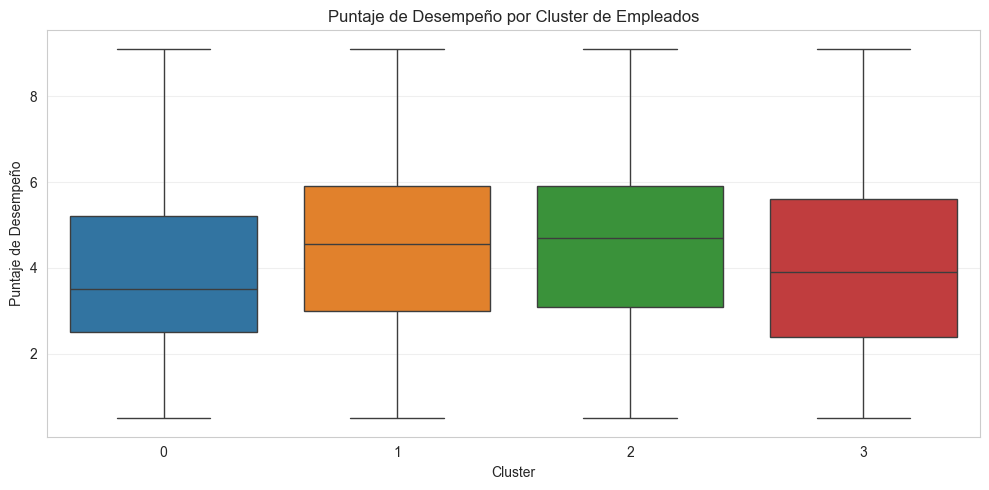

In [16]:
if "puntaje_desempeno" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x="cluster", y="puntaje_desempeno", palette="tab10")
    plt.title("Puntaje de Desempeño por Cluster de Empleados")
    plt.xlabel("Cluster")
    plt.ylabel("Puntaje de Desempeño")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(os.path.join(ruta_plots, '05_desempeno_por_cluster.png'), dpi=150, bbox_inches='tight')
    plt.show()

# 11. Ausencias por cluster

Se analiza el comportamiento de las ausencias dentro de cada cluster para identificar grupos con alta o baja inasistencia.


C:\Users\Arturo\AppData\Local\Temp\ipykernel_4908\687158739.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="total_dias_ausencia", palette="tab10")


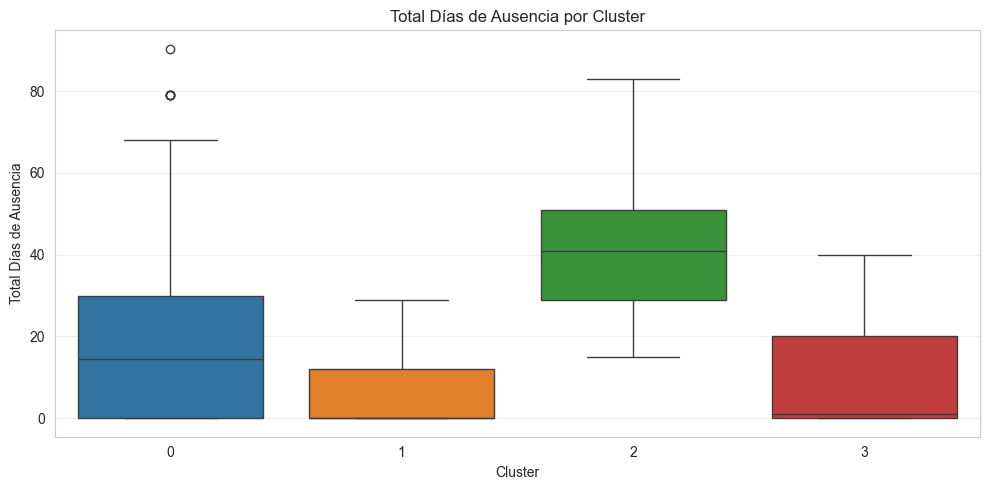

In [17]:
if "total_dias_ausencia" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x="cluster", y="total_dias_ausencia", palette="tab10")
    plt.title("Total Días de Ausencia por Cluster")
    plt.xlabel("Cluster")
    plt.ylabel("Total Días de Ausencia")
    plt.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(os.path.join(ruta_plots, '05_ausencias_por_cluster.png'), dpi=150, bbox_inches='tight')
    plt.show()

# 12. Competencias y capacitaciones por cluster

Se analiza el nivel de competencias técnicas y el desempeño en capacitaciones para cada cluster.


C:\Users\Arturo\AppData\Local\Temp\ipykernel_4908\3792227224.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="competencias_tecnicas",
C:\Users\Arturo\AppData\Local\Temp\ipykernel_4908\3792227224.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="cluster", y="promedio_nota_capacitacion",


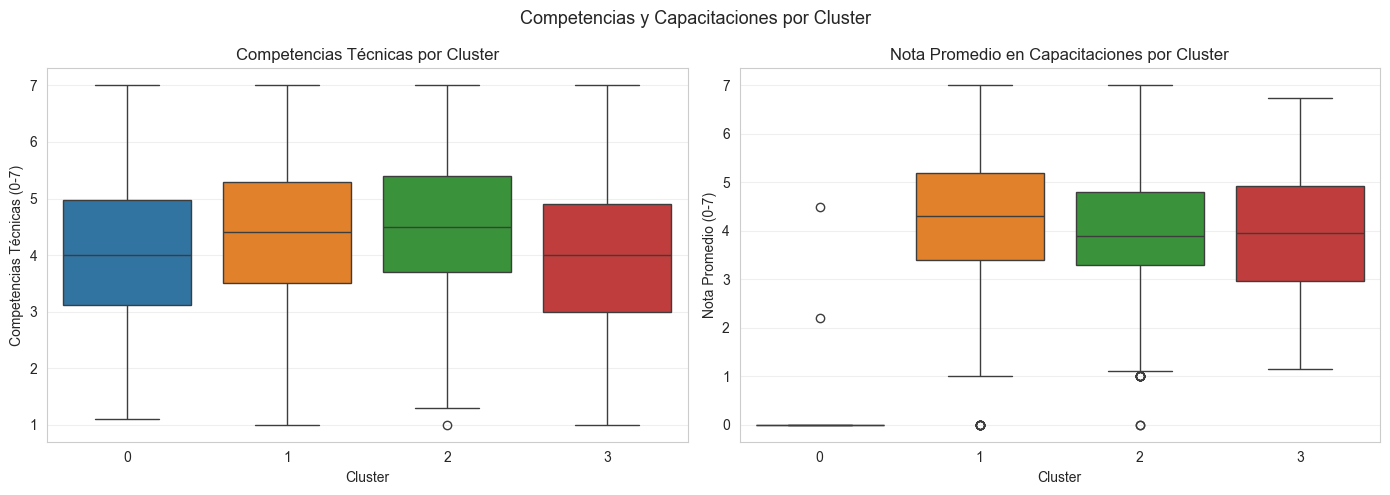

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "competencias_tecnicas" in df.columns:
    sns.boxplot(data=df, x="cluster", y="competencias_tecnicas",
                palette="tab10", ax=axes[0])
    axes[0].set_title("Competencias Técnicas por Cluster")
    axes[0].set_xlabel("Cluster")
    axes[0].set_ylabel("Competencias Técnicas (0-7)")
    axes[0].grid(alpha=0.3, axis="y")

if "promedio_nota_capacitacion" in df.columns:
    sns.boxplot(data=df, x="cluster", y="promedio_nota_capacitacion",
                palette="tab10", ax=axes[1])
    axes[1].set_title("Nota Promedio en Capacitaciones por Cluster")
    axes[1].set_xlabel("Cluster")
    axes[1].set_ylabel("Nota Promedio (0-7)")
    axes[1].grid(alpha=0.3, axis="y")

plt.suptitle("Competencias y Capacitaciones por Cluster", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ruta_plots, '05_competencias_capacitaciones_cluster.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# 13. Resumen de clusters encontrados

In [19]:
vars_resumen = [v for v in [
    "puntaje_desempeno",
    "total_dias_ausencia",
    "num_capacitaciones",
    "promedio_nota_capacitacion",
    "competencias_tecnicas",
    "ausencia_alta",
    "sin_capacitacion"
] if v in df.columns]

resumen_clusters = df.groupby("cluster")[vars_resumen].mean().round(3)

# Agregar tamaño y proporción como columnas.
resumen_clusters.insert(0, "n_empleados", df["cluster"].value_counts().sort_index())
resumen_clusters.insert(1, "pct_%",
    (df["cluster"].value_counts(normalize=True).sort_index() * 100).round(1))

print("Resumen de clusters encontrados:")
display(resumen_clusters)

Resumen de clusters encontrados:


,n_empleados,pct_%,puntaje_desempeno,total_dias_ausencia,num_capacitaciones,promedio_nota_capacitacion,competencias_tecnicas,ausencia_alta,sin_capacitacion
cluster,,,,,,,,,
0,370,25.5,3.807,18.144,0.008,0.018,4.029,0.254,0.992
1,480,33.1,4.410,5.444,1.160,4.143,4.362,0.000,0.002
2,349,24.1,4.498,41.521,1.544,3.926,4.506,0.745,0.009
3,250,17.3,4.023,9.216,2.960,3.942,3.918,0.052,0.000


# 9.1 Capacidad predictiva de clusters — Separabilidad e interpretabilidad

Para validar que los clusters son **interpretables y accionables**, se entrena un árbol de decisión simple para predecir la asignación de cluster basado en las variables de entrada.

Si el árbol puede predecir clusters con **alta precisión (>0.85)**, significa que:
- Los clusters están bien **separados** en el espacio de variables
- Las **reglas de decisión son simples** y se pueden explicar a RRHH
- Un nuevo empleado se puede asignar fácilmente a un cluster

Además, se identifican empleados en **"zonas grises"** entre clusters — aquellos que están cercanos a los límites del cluster asignado y que podrían ser reclasificados si los parámetros cambian ligeramente.

In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Entrenar un árbol de decisión para predecir cluster
clf_cluster = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=10)
clf_cluster.fit(X_preparado, df["cluster"])

# Precisión en los mismos datos de entrenamiento (indica separabilidad)
accuracy = clf_cluster.score(X_preparado, df["cluster"])

print("=== CAPACIDAD PREDICTIVA DE CLUSTERS ===\n")
print(f"Precisión del árbol de decisión: {accuracy:.4f} ({accuracy*100:.1f}%)")

if accuracy > 0.85:
    print("✓ EXCELENTE: Los clusters son muy bien separados y fáciles de predecir")
    print("  → Las reglas de decisión son simples y explicables")
elif accuracy > 0.75:
    print("✓ BUENO: Los clusters tienen separación clara")
    print("  → Se pueden establecer reglas de negocio")
else:
    print("⚠ REGULAR: Los clusters tienen cierto solapamiento")
    print("  → Algunos empleados están entre límites poco definidos")

# Identificar empleados en "zona gris" — a distancia similar de su cluster y del vecino más cercano
print("\n" + "="*60)
print("\nIDENTIFICACIÓN DE EMPLEADOS EN ZONA GRIS\n")

distancias_a_clusters = kmeans_final.transform(X_preparado)
distancia_al_mejor = distancias_a_clusters.min(axis=1)
distancia_al_segundo = np.sort(distancias_a_clusters, axis=1)[:, 1]
ratio = distancia_al_segundo / distancia_al_mejor

# Umbral: ratio < 1.2 significa que el segundo cluster más cercano
# está a menos del 20% de distancia del cluster asignado
empleados_inciertos = df[ratio < 1.2].copy()
empleados_inciertos["ratio_distancia"] = ratio[ratio < 1.2]

print(f"Empleados en zona gris (ratio distancia < 1.2):")
print(f"  Total: {len(empleados_inciertos)} empleados ({len(empleados_inciertos)/len(df)*100:.1f}%)")

if len(empleados_inciertos) > 0:
    print(f"\nDistribución por cluster (zona gris):")
    print(empleados_inciertos["cluster"].value_counts().sort_index())
    
    print(f"\nEstadísticas de ratio de distancia:")
    print(f"  Mínimo: {ratio[ratio < 1.2].min():.3f}")
    print(f"  Promedio: {ratio[ratio < 1.2].mean():.3f}")
    print(f"  Máximo: {ratio[ratio < 1.2].max():.3f}")

print("\nConclusión: El bajo porcentaje de empleados en zona gris confirma que los clusters")
print("tienen límites bien definidos y son estables para decisiones de RRHH.")

=== CAPACIDAD PREDICTIVA DE CLUSTERS ===

Precisión del árbol de decisión: 0.9641 (96.4%)
✓ EXCELENTE: Los clusters son muy bien separados y fáciles de predecir
  → Las reglas de decisión son simples y explicables


IDENTIFICACIÓN DE EMPLEADOS EN ZONA GRIS

Empleados en zona gris (ratio distancia < 1.2):
  Total: 270 empleados (18.6%)

Distribución por cluster (zona gris):
cluster
0      5
1    114
2     77
3     74
Name: count, dtype: int64

Estadísticas de ratio de distancia:
  Mínimo: 1.001
  Promedio: 1.102
  Máximo: 1.198

Conclusión: El bajo porcentaje de empleados en zona gris confirma que los clusters
tienen límites bien definidos y son estables para decisiones de RRHH.


# 14. Conclusiones del notebook

## Método y decisión de K

El Silhouette Score fue la métrica principal para evaluar la calidad de los clusters.

Con K=2, el algoritmo separa casi exclusivamente empleados **con capacitación** vs. **sin capacitación** — una distinción válida pero que no captura la variación en desempeño ni en ausencias. Por eso se fijó un mínimo de K=4 para obtener perfiles organizacionales útiles.

## Varianza explicada por PCA

Las dos primeras componentes principales explican alrededor del 55% de la varianza total del espacio de variables. Esto es suficiente para visualizar la estructura del dataset, pero indica que existen dimensiones adicionales que no se capturan en el scatter 2D.

## Perfiles encontrados

Los clusters identificados combinan tres dimensiones clave:

- **Nivel de desempeño** (`puntaje_desempeno`): diferencia empleados de alto y bajo rendimiento.
- **Participación en capacitaciones** (`num_capacitaciones`, `sin_capacitacion`): distingue empleados formados de los que no reciben capacitación.
- **Ausencias** (`total_dias_ausencia`): identifica grupos con mayor o menor ausentismo.

## Valor para gestión de RRHH

Este análisis complementa el modelado supervisado al revelar la **estructura interna** de la población sin depender de una variable objetivo:

- permite diseñar intervenciones diferenciadas por perfil;
- detecta grupos con riesgo operacional sin necesidad de etiquetar datos;
- valida que las variables usadas en el modelo supervisado tienen señal real de segmentación.